# Задача по анализу поиска в Яндекс Картинках

**Задача:** проверить гипотезу о том, что интересы пользователей поиска по картинкам заметно отличаются на мобильных устройствах (touch) и на компьютерах (desktop), сравнив запросы на двух платформах.

Изучим содержимое файла: посмотрим, как выглядит первые строки таблицы. Проверим количество запросов на каждом из устройств

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandasql import sqldf

df = pd.read_csv('data.tsv', sep='\t', header=None, names=['query', 'ts', 'platform'])
print('Всего строк:', len(df))
print(df['platform'].value_counts())
df.head()

Всего строк: 1114365
platform
touch      726101
desktop    388264
Name: count, dtype: int64


,query,ts,platform
0,малевич картины,1631806465,desktop
1,психология,1631781583,touch
2,с днём рождения лена,1631771563,touch
3,зверополис фильмы,1631787599,touch
4,алабай собака фото,1631786645,touch


## 1. Диапазон данных

Проверим данные на пропуски и дубликаты, плюс переведём unix-время в читаемый вид.


In [3]:
print('Пропуски:')
print(df.isna().sum())
print('Полных дублей строк:', df.duplicated().sum())

df['dt_utc'] = pd.to_datetime(df['ts'], unit='s')
print('\nВременной интервал (UTC):', df['dt_utc'].min(), '-', df['dt_utc'].max())


Пропуски:
query       0
ts          0
platform    0
dtype: int64
Полных дублей строк: 435

Временной интервал (UTC): 2021-08-31 21:00:00 - 2021-09-21 20:59:59


Из-за того, что выдаваемые данные смещены от полноценной недели на 3 часа можно предположить, что необходимо смещение в UTC+3. В таком случае диапазон дат становится ровно 21 полный день, а суточный профиль трафика выглядит естественно (минимум ночью, пик вечером). Поэтому дальше в анализе везде используется московское время.

In [4]:
df['dt_msk'] = df['dt_utc'] + pd.Timedelta(hours=3)
df['date_msk'] = df['dt_msk'].dt.date
df['hour_msk'] = df['dt_msk'].dt.hour

print('После сдвига в МСК (UTC+3):     ', df['dt_msk'].min(), '-', df['dt_msk'].max())
print('Количество дней в выборке (МСК):', df['date_msk'].nunique())

После сдвига в МСК (UTC+3):      2021-09-01 00:00:00 - 2021-09-21 23:59:59
Количество дней в выборке (МСК): 21


Количество запросов в каждый из дней диапазона представлено ниже

Диапазон: 2021-09-01 — 2021-09-21


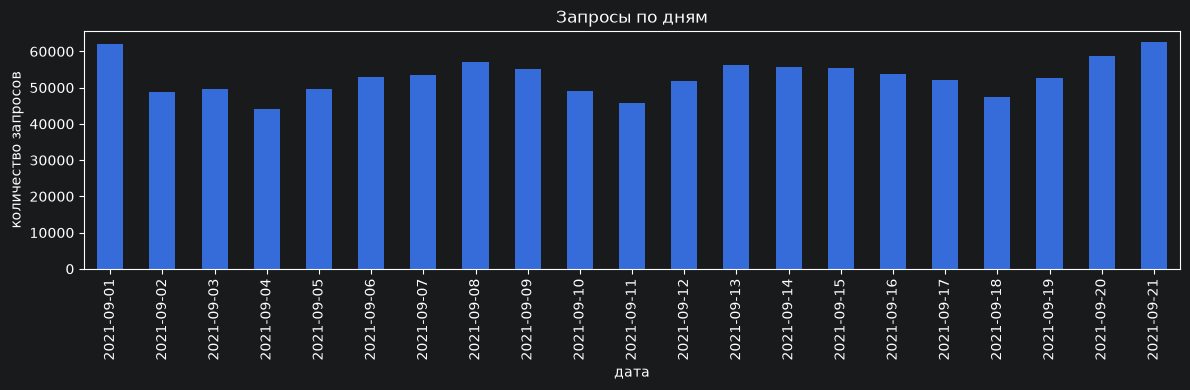

In [5]:
print('Диапазон:', df['date_msk'].min(), '—', df['date_msk'].max())
df.groupby('date_msk').size().plot(kind='bar', figsize=(12,4), title='Запросы по дням')
plt.ylabel('количество запросов')
plt.xlabel('дата')
plt.tight_layout()
plt.show()

## 2. Запросы со словом «ютуб»

Текст задания: Рассчитайте кол-во запросов с текстом «ютуб» в каждой платформе (desktop, touch)

Считаем запросы, где текст содержит подстроку «ютуб» (регистронезависимо). Латинское написание `YouTube` не учитываем, т.к. в задании указан текст «ютуб» (кириллица).

In [6]:
df['query_lower'] = df['query'].str.lower()

q = """
SELECT platform, COUNT(*) AS n_queries
FROM df
WHERE query_lower LIKE '%ютуб%'
GROUP BY platform
ORDER BY n_queries DESC
"""
sqldf(q, {'df': df})

,platform,n_queries
0,desktop,806
1,touch,732


Общее количество запросов на мобильных устройствах — больше, поэтому проверим процентное соотношение данного вида трафика

In [7]:
contains_mask = df['query'].str.contains('ютуб', case=False, na=False)
share_d = contains_mask[df['platform']=='desktop'].mean()*100
share_t = contains_mask[df['platform']=='touch'].mean()*100
print(f'Доля запросов "ютуб" от всех запросов platform=desktop: {share_d:.3f}%')
print(f'Доля запросов "ютуб" от всех запросов platform=touch:   {share_t:.3f}%')

Доля запросов "ютуб" от всех запросов platform=desktop: 0.208%
Доля запросов "ютуб" от всех запросов platform=touch:   0.101%


**Вывод:** Компьютерные и мобильные устройства дают близкие абсолютные числа (~800 и ~730), но с учётом того, что тач-трафика почти вдвое больше по объёму, доля запросов про YouTube заметно выше на desktop. Ютуб на компьютере ищут в картинках чаще (например, чтобы найти логотип), чем с телефона. Также есть вероятность, что ютуб с компьютера в картинках могут случайно искать, забыв переключиться на обычный поиск (в таком сценарии телефон используют реже, потому что заход в ютуб происходит через приложение).

## 3. Топ-10 частотных запросов в каждой платформе

In [8]:
top_desktop = df[df['platform']=='desktop']['query'].value_counts().head(10)
top_touch = df[df['platform']=='touch']['query'].value_counts().head(10)

comparison = pd.concat([top_desktop.reset_index().rename(columns={'index':'query_desktop','query':'count_desktop'}),
                         top_touch.reset_index().rename(columns={'index':'query_touch','query':'count_touch'})], axis=1)
comparison

,count_desktop,count,count_touch,count
0,календарь 2021,2804,с днём рождения женщине,4903
1,таблица менделеева,2631,с днём рождения,3967
2,картинки,1647,с днём рождения мужчине,3623
3,английский алфавит,1293,с днем рождения,3005
4,обои на рабочий стол,1143,погода,2840
5,Одноклассники (социальная сеть),1116,игры,2833
6,таблица квадратов,877,фильмы,2746
7,алфавит,874,новости,2708
8,таблица умножения,867,музыка,2696
9,карта мира,795,мода,2648


### Какие отличия видны:

- На компьютерных устройствах в основном справочно-рабочие запросы: календарь на год, таблица Менделеева, английский алфавит, таблицы умножения/квадратов, формулы сокращённого умножения, карта мира/России, «Одноклассники». Это похоже на запросы, которые нужны во время дела (учёба, работа).
- На мобильных устройствах запросы, которые могут появиться во время обычных жизненных ситуаций (эмоционально-бытовые и лайфстайл-запросы): «с днём рождения» во всех вариациях (женщине/мужчине/подруге), «доброе утро», погода, игры, фильмы, музыка, мода. Люди со смартфона ищут картинки, чтобы **сразу переслать** (открытка/поздравление) или посмотреть «между делом».

## 4. Трафик в течение суток

Смотрим распределение запросов по часам (МСК) отдельно для каждой платформы.

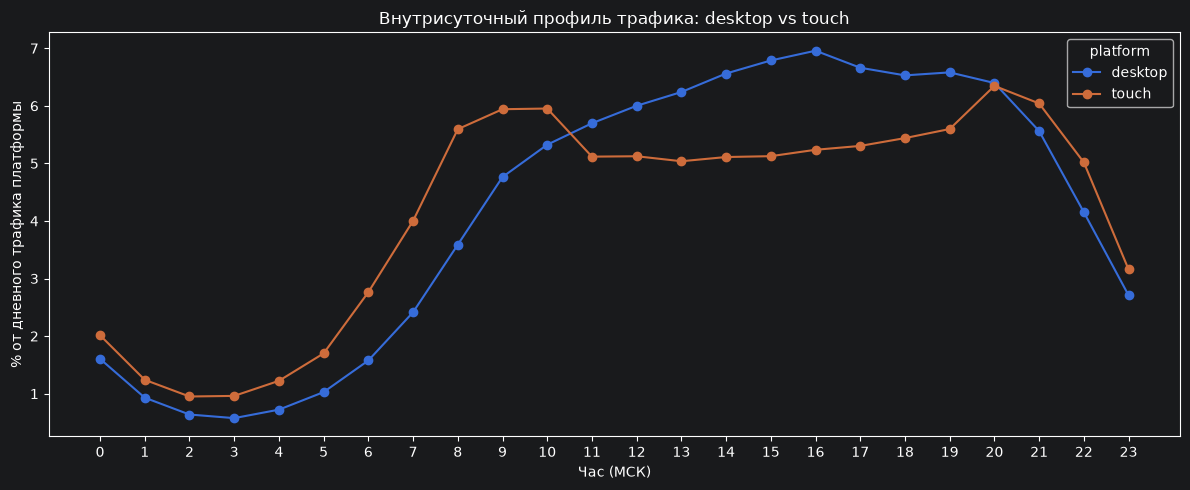

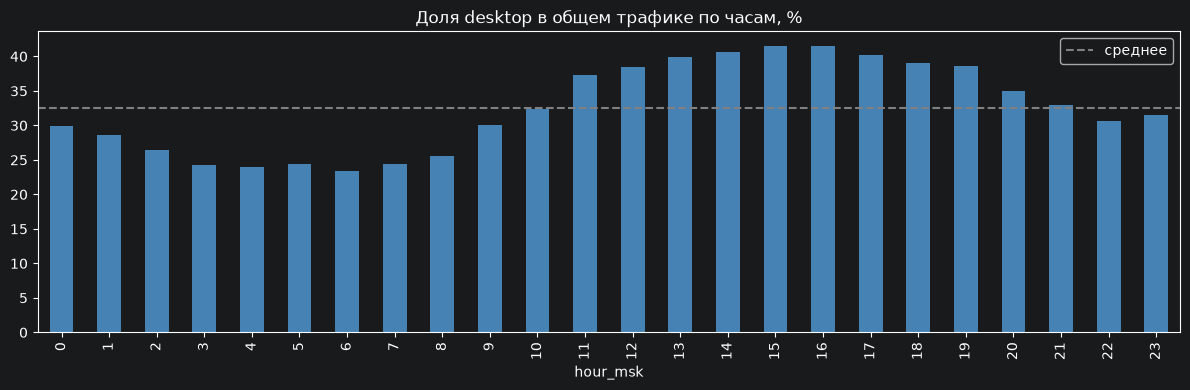

In [9]:
hourly = df.groupby(['hour_msk','platform']).size().unstack(fill_value=0)
hourly_pct = hourly.div(hourly.sum(axis=0), axis=1) * 100

ax = hourly_pct.plot(figsize=(12,5), marker='o')
ax.set_xlabel('Час (МСК)')
ax.set_ylabel('% от дневного трафика платформы')
ax.set_title('Внутрисуточный профиль трафика: desktop vs touch')
ax.set_xticks(range(0,24))
plt.tight_layout()
plt.show()

# доля desktop в каждый час (из общего трафика в этот час)
desktop_share_by_hour = (hourly['desktop'] / hourly.sum(axis=1) * 100)
desktop_share_by_hour.plot(kind='bar', figsize=(12,4), color='steelblue', title='Доля desktop в общем трафике по часам, %')
plt.axhline(desktop_share_by_hour.mean(), color='gray', linestyle='--', label='среднее')
plt.legend()
plt.tight_layout()
plt.show()

### Выводы

- Доля **desktop** в общем трафике минимальна ночью (\~24%, 00:00–6:00 МСК) и максимальна в рабочие часы (~40–42%, 11:00–18:00) — из-за того, что доля растёт с началом рабочего дня и падает к вечеру.
- **Touch**, наоборот, держит стабильно высокую долю трафика утром (до работы/учёбы) и особенно вечером (20:00–21:00 — пик всего трафика вообще), когда телефон — основное устройство для досуга перед сном.
- Ночной провал (00:00–6:00) есть у обеих платформ (люди спят), но он глубже для desktop — компьютер ночью почти не используют, а с телефоном кто-то всё ещё листает картинки.

Это напрямую подтверждает гипотезу задания: **desktop привязан к рабочему графику, touch — к личному времени и постоянно «под рукой».**

## 5. Контрастные тематики

Сравнивать по одной топ-фразе неудобно — одинаковый смысл выражается разными формулировками («с днём рождения» / «с днём рождения женщине» / «поздравления с днём рождения женщине»). Поэтому группируем запросы в смысловые темы по ключевым словам/regex и считаем **долю каждой темы от всех запросов платформы** (а не абсолютное число) — так платформы с разным объёмом трафика сравнимы. Контраст — это отношение доли на touch к доле на desktop.

In [10]:
categories = {
    'Открытки/поздравления (др, доброе утро, 1 сентября)': r'день рожден|доброе утро|поздравлен|открытк|1 сентября|с 8 марта|с новым годом',
    'Обои на телефон': r'обои на телефон|обои на айфон',
    'Обои на рабочий стол': r'обои на рабочий стол|обои на комп',
    'Карты метро/навигация': r'карт[а-я]* метро|схема метро',
    'Раскраски/для детей': r'раскраск|для детей|детские',
    'Соцсети (Одноклассники/ВК)': r'одноклассник|вконтакте|\bвк\b',
    'Справочные таблицы (школа)': r'таблиц[а-я]* менделеева|таблиц[а-я]* умножен|таблиц[а-я]* квадрат|формул[а-я]* сокращ|алфавит',
    'Календари': r'календарь',
    'Погода (точный запрос "погода")': r'^погода$',
    'Односложные темы-«чипы» (мода/спорт/наука и т.п.)': r'^(мода|спорт|наука|технологии|психология|путешествия|история|образование|кулинария|здоровье|кино|литература|игры|фильмы|музыка|новости)$',
}

totals = df['platform'].value_counts()
rows = []
for name, pattern in categories.items():
    mask = df['query'].str.contains(pattern, case=False, regex=True, na=False)
    cnt = df[mask]['platform'].value_counts().reindex(['desktop','touch']).fillna(0)
    share_d = cnt['desktop'] / totals['desktop'] * 100
    share_t = cnt['touch'] / totals['touch'] * 100
    ratio = (share_t + 1e-6) / (share_d + 1e-6)
    rows.append([name, int(cnt['desktop']), int(cnt['touch']), round(share_d,3), round(share_t,3), round(ratio,2)])

contrast = pd.DataFrame(rows, columns=['Тема','n_desktop','n_touch','share_desktop_%','share_touch_%','ratio_touch/desktop'])
contrast = contrast.sort_values('ratio_touch/desktop', ascending=False).reset_index(drop=True)
contrast

/var/folders/c9/hk16qjds3g58ccz51dx1cl2w0000gn/T/ipykernel_88152/740000056.py:17: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = df['query'].str.contains(pattern, case=False, regex=True, na=False)


,Тема,n_desktop,n_touch,share_desktop_%,share_touch_%,ratio_touch/desktop
0,Обои на телефон,179,3942,0.046,0.543,11.78
1,"Открытки/поздравления (др, доброе утро, 1 сент...",5858,47403,1.509,6.528,4.33
2,"Погода (точный запрос ""погода"")",501,2918,0.129,0.402,3.11
3,Односложные темы-«чипы» (мода/спорт/наука и т.п.),7174,39325,1.848,5.416,2.93
4,Карты метро/навигация,1963,7821,0.506,1.077,2.13
5,Справочные таблицы (школа),11963,11703,3.081,1.612,0.52
6,Календари,9797,6488,2.523,0.894,0.35
7,Соцсети (Одноклассники/ВК),2168,928,0.558,0.128,0.23
8,Раскраски/для детей,9823,2177,2.530,0.300,0.12
9,Обои на рабочий стол,2902,204,0.747,0.028,0.04


**Контрастные темы (touch > desktop):**
- **Обои на телефон** — тематика по определению мобильная (x11.5 контраст), логичный контроль качества разметки на «привязанные к платформе» темы.
- **Открытки и поздравления** — в 4.3 раза выше доля на touch, потому что удобнее сразу переслалать в мессенджер.
- **Погода** и **«темы-чипы»** (мода/спорт/наука/...) — заметно выше на мобильных устройствах и скорее всего используются пользователями, чтобы "позалипать" вместо листания соц. сетей (как и соц. сети делается это на телефоне).

**Контрастные темы (desktop > touch):**
- **Обои на рабочий стол** — зеркальная история к «обои на телефон» (x0.04, т.е. почти весь объём на desktop).
- **Раскраски/для детей** — в 8 раз выше доля на desktop: раскраски обычно распечатывают, а принтер почти всегда подключён к компьютеру.
- **Календари** и **соцсети (Одноклассники/ВК)** — тоже выше на desktop из-за рабочего формата использования. Также есть вероятность случайного поиска, когда пользователь хотел зайти в соц. сеть, но в итоге искал в картинках (такой сценарий меньше вероятен на телефоне из-за наличия отдельных приложений, что также видно в статистике)
- **Справочные таблицы для школы** (таблица Менделеева, алфавит, формулы) — выше на desktop: делают уроки/распечатывают материалы за компьютером.

## Итоговые выводы

1. **Диапазон данных:** 1–21 сентября 2021 (МСК), 21 день.
2. **«Ютуб»:** ~800 запросов на desktop и ~730 на touch в абсолюте, но с учётом объёма трафика доля выше на компьютерах.
3. **Топ-10:** компьютерные устройства — справочно-рабочие запросы (календарь, таблица Менделеева, алфавит, карты), мобильные устройства — личные/эмоциональные (поздравления, погода, игры, фильмы, мода).
4. **Суточный профиль:** доля компьютеров растёт в рабочие часы и падает ночью/вечером — типичный рабочий инструмент; телефон стабильно высок весь день с пиком вечером, потому что всегда под рукой.
5. **Контрастные темы:** обои (телефон vs рабочий стол) — почти идеальный контрольный пример методики; открытки/поздравления смещены в телефонов; раскраски, календари и школьные справочные материалы — в компьютере (из-за необходимости печати и работы).

## Итог по гипотезе задания
Гипотеза подтверждается — компьютерные и мобильные устройства различаются не только по объёму, но и по характеру запросов: в основном компьютер используют в рабочих/учебных сценариях и для поиска картинок для печати.

Часть визуализации данных для сравнения компьютерных и мобильных устройств можно посмотреть по ссылке: https://datalens.yandex/91tcucl4nx6ws